# Linear cellular sheaves, Gate 1: the smallest useful example

This notebook builds a cellular sheaf on a three-node path. It is deliberately smaller than the barcode problem: the goal is to understand each mathematical object before introducing overlapping barcode windows.

By the end of this gate, we will be able to explain and compute:

- vertex and edge **stalks**;
- **restriction maps** from vertices to incident edges;
- the **coboundary** $\delta$ and sheaf Laplacian $L_{\mathcal F}=\delta^\top\delta$;
- compatible assignments, or **global sections**;
- pure diffusion versus confidence-weighted recovery.

> Scope boundary: this gate stops at scalar consensus. It does not yet model barcode bars, blur, or multiple scanlines.

In [1]:
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

SEED = 7
rng = np.random.default_rng(SEED)

print(f'Python: {platform.python_version()}')
print(f'NumPy: {np.__version__}')
print(f'Matplotlib: {matplotlib.__version__}')
print(f'Executable: {sys.executable}')
print(f'Random seed: {SEED}')

Python: 3.12.3
NumPy: 1.26.4
Matplotlib: 3.6.3
Executable: /usr/bin/python3
Random seed: 7


## 1. Put local data on a graph

Our base space is the path $v_0 \rightarrow v_1 \rightarrow v_2$, with edges $e_0=(v_0,v_1)$ and $e_1=(v_1,v_2)$.

Every vertex and edge receives a one-dimensional real vector space $\mathbb R$ as its stalk. Both restriction maps incident to an edge are the identity. Therefore, two neighboring vertex values are compatible exactly when they are equal.

For an oriented edge $e=(u,v)$, the coboundary records disagreement:

$$
(\delta x)_e = \mathcal F_{v\to e}x_v - \mathcal F_{u\to e}x_u = x_v-x_u.
$$

Coboundary delta:
[[-1.  1.  0.]
 [ 0. -1.  1.]]

Sheaf Laplacian L = delta.T @ delta:
[[ 1. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  1.]]


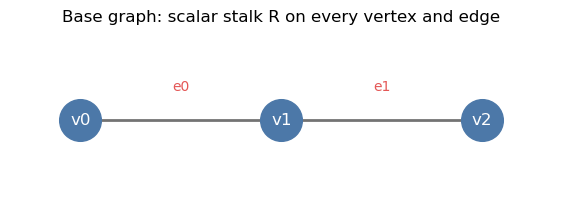

In [2]:
vertices = ('v0', 'v1', 'v2')
edges = (('v0', 'v1'), ('v1', 'v2'))

# Rows correspond to oriented edges; columns correspond to vertices.
delta = np.array([
    [-1.0,  1.0,  0.0],
    [ 0.0, -1.0,  1.0],
])
L = delta.T @ delta

print('Coboundary delta:')
print(delta)
print('\nSheaf Laplacian L = delta.T @ delta:')
print(L)

fig, ax = plt.subplots(figsize=(7, 2.2))
positions = np.array([[0.0, 0.0], [1.0, 0.0], [2.0, 0.0]])
ax.plot(positions[:, 0], positions[:, 1], color='0.45', linewidth=2, zorder=1)
ax.scatter(positions[:, 0], positions[:, 1], s=900, color='#4C78A8', zorder=2)
for (x_pos, y_pos), label in zip(positions, vertices):
    ax.text(x_pos, y_pos, label, ha='center', va='center', color='white', fontsize=12)
for edge_index, midpoint in enumerate((0.5, 1.5)):
    ax.text(midpoint, 0.13, f'e{edge_index}', ha='center', color='#E45756')
ax.set(xlim=(-0.35, 2.35), ylim=(-0.35, 0.4), title='Base graph: scalar stalk R on every vertex and edge')
ax.axis('off')
plt.show()

## 2. Compatibility, energy, and global sections

A vertex assignment $x=(x_0,x_1,x_2)$ is a global section when every overlap agrees, so $\delta x=0$. The constant assignment is compatible; a nonconstant assignment is not.

The total disagreement energy has two equivalent forms:

$$
E(x)=\lVert\delta x\rVert_2^2=x^\top L_{\mathcal F}x.
$$

Because $L_{\mathcal F}=\delta^\top\delta$, it is symmetric positive semidefinite. Its zero-eigenvalue eigenvectors are precisely the global sections in this example.

In [3]:
x_global = np.array([1.0, 1.0, 1.0])
x_inconsistent = np.array([1.0, -0.5, 0.8])

def consistency_energy(x):
    return float(np.linalg.norm(delta @ x) ** 2)

eigenvalues = np.linalg.eigvalsh(L)

print(f'delta @ global section: {delta @ x_global}')
print(f'delta @ inconsistent assignment: {delta @ x_inconsistent}')
print(f'inconsistent energy: {consistency_energy(x_inconsistent):.3f}')
print(f'Laplacian eigenvalues: {eigenvalues}')

assert delta.shape == (2, 3)
assert L.shape == (3, 3)
assert np.allclose(L, L.T)
assert np.all(eigenvalues >= -1e-12)
assert np.count_nonzero(np.isclose(eigenvalues, 0.0, atol=1e-12)) == 1
assert np.allclose(delta @ x_global, 0.0)
assert np.isclose(consistency_energy(x_inconsistent), x_inconsistent @ L @ x_inconsistent)

delta @ global section: [0. 0.]
delta @ inconsistent assignment: [-1.5  1.3]
inconsistent energy: 3.940
Laplacian eigenvalues: [3.92505363e-17 1.00000000e+00 3.00000000e+00]


## 3. Diffusion is not the same as restoration

The update $x_{t+1}=x_t-\alpha L_{\mathcal F}x_t$ decreases disagreement when the step size is stable. With this connected identity sheaf, however, pure diffusion ultimately keeps only the mean of the initial observations. It has no term requiring the result to explain trusted measurements.

For restoration, add data fidelity and confidence. Let $y$ be the measurements and $W=\operatorname{diag}(w_i)$ their confidence matrix. We solve

$$
\hat x=\arg\min_x (x-y)^\top W(x-y)+\lambda x^\top L_{\mathcal F}x,
$$

whose unique solution for positive confidence is

$$
(W+\lambda L_{\mathcal F})\hat x=Wy.
$$

In [4]:
truth = np.ones(3)
observed = np.array([1.05, -0.80, 0.90])  # The center measurement is corrupted.
confidence = np.array([1.0, 0.03, 1.0])
W = np.diag(confidence)
regularization = 1.0

weighted_solution = np.linalg.solve(W + regularization * L, W @ observed)
unweighted_solution = np.linalg.solve(np.eye(3) + regularization * L, observed)

alpha = 0.25  # Stable because alpha < 2 / largest_eigenvalue(L).
diffused = observed.copy()
diffusion_history = [diffused.copy()]
for _ in range(40):
    diffused = diffused - alpha * (L @ diffused)
    diffusion_history.append(diffused.copy())
diffusion_history = np.asarray(diffusion_history)

def weighted_data_error(x):
    residual = x - observed
    return float(residual @ W @ residual)

print(f'truth:               {truth}')
print(f'observed:            {observed}')
print(f'pure diffusion:      {diffused.round(4)}')
print(f'unweighted solution: {unweighted_solution.round(4)}')
print(f'weighted solution:   {weighted_solution.round(4)}')
print()
print(f'observed consistency energy: {consistency_energy(observed):.4f}')
print(f'weighted consistency energy: {consistency_energy(weighted_solution):.4f}')
print(f'weighted data error:          {weighted_data_error(weighted_solution):.4f}')

assert np.all(np.isfinite(weighted_solution))
assert consistency_energy(diffused) < consistency_energy(observed)
assert consistency_energy(weighted_solution) < consistency_energy(observed)
assert np.linalg.norm(weighted_solution - truth) < np.linalg.norm(observed - truth)

truth:               [1. 1. 1.]
observed:            [ 1.05 -0.8   0.9 ]
pure diffusion:      [0.3833 0.3833 0.3833]
unweighted solution: [0.5688 0.0875 0.4938]
weighted solution:   [0.9867 0.9233 0.9117]

observed consistency energy: 6.3125
weighted consistency energy: 0.0041
weighted data error:          0.0932


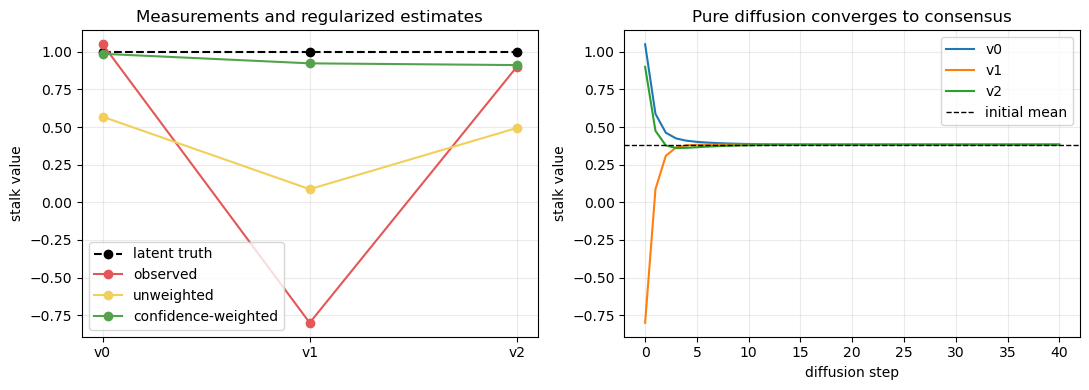

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

module_index = np.arange(3)
axes[0].plot(module_index, truth, 'k--', marker='o', label='latent truth')
axes[0].plot(module_index, observed, color='#E45756', marker='o', label='observed')
axes[0].plot(module_index, unweighted_solution, color='#F2CF5B', marker='o', label='unweighted')
axes[0].plot(module_index, weighted_solution, color='#54A24B', marker='o', label='confidence-weighted')
axes[0].set(xticks=module_index, xticklabels=vertices, ylabel='stalk value', title='Measurements and regularized estimates')
axes[0].legend()
axes[0].grid(alpha=0.25)

for vertex_index, vertex in enumerate(vertices):
    axes[1].plot(diffusion_history[:, vertex_index], label=vertex)
axes[1].axhline(observed.mean(), color='k', linestyle='--', linewidth=1, label='initial mean')
axes[1].set(xlabel='diffusion step', ylabel='stalk value', title='Pure diffusion converges to consensus')
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

## 4. What this teaches—and what it does not

We now have the complete linear cellular-sheaf pipeline in miniature:

1. the graph says which local data interact;
2. stalks say what data live at each graph cell;
3. restriction maps say what neighboring data must agree about;
4. $\delta$ measures every local disagreement;
5. $L_{\mathcal F}$ aggregates those disagreements;
6. confidence-weighted regularization balances agreement with evidence.

The restriction maps are the modeling decision. Identity maps on scalar stalks demand equality everywhere, which is useful for learning consensus but wrong for a barcode: neighboring barcode modules are allowed to differ. The next gate should use vector stalks for overlapping windows and coordinate-selection restriction maps. Those maps will require agreement only where two windows describe the same underlying module.

This notebook intentionally stops here.

### Reference

Jakob Hansen and Robert Ghrist, [*Toward a Spectral Theory of Cellular Sheaves*](https://arxiv.org/abs/1808.01513).